In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad
import torch

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

### Add mbt-gym to path

In [14]:
import sys
sys.path.append("../")
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

### Add MM Fads path

In [15]:
# Notebook for the paper: MM with informed and uninformed traders
import pickle

with open('./MM_Fads_Adrien/params_env.pkl', 'rb') as f:
    params_env = pickle.load(f)    
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (8, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)
%config InlineBackend.figure_format = "retina"

import matplotlib

import MM_Fads_Adrien.utils as utils
from importlib import reload
mm = utils.mm_with_fads(**params_env)

psi is  14.872343376978963
Adrien phi, varphi, psi, k, alpha 0.1 15 14.872343376978963 1 0.001
Adrien self.delta_t: 0.001
Adrien self.N_t: 1000


In [16]:
params_env['N_t'] = 20  # Number of time steps for the SB env
params_env['alpha'] = 0.001
params_env['phi'] = 0.1
params_env['T'] = 10

In [17]:
print(params_env)

{'k': 1, 'phi': 0.1, 'alpha': 0.001, 'q_bar': 50, 'T': 10, 'N_t': 20, 'N_u': 100, 'U_max': 10, 'sigma': 1, 'eta': 10, 'qconst': 0.6, 'mu': 0, 'Q_0': 0, 'X_0': 0, 'S_0': 100, 'U_0': 0, 'varphi': 15, 'total_arrivals': 30, 'gamma': 1, 'matrixCJ': []}


### Parameters

In [18]:
max_inventory = 50

seed = 42

In [19]:
initial_price = 100
terminal_time = 10.0
sigma = 1.0
n_steps = 20
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [20]:
# # OU parameters
# u0 = 0.0
# xi = 1.0

# def m(t):
#     return u0 * np.exp(-eta * t)

# def v(t):
#     return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

# def compute_psi(q):
#     c = gamma * sigma * q
#     def integrand(t):
#         return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
#     denom, _ = quad(integrand, 0.0, terminal_time)
#     return (30.0 - phi * terminal_time) / denom

# # compute psi for each fad proportion
# psi = compute_psi(fads_proportion)

# print("psi value:", psi)

In [21]:
total_arrivals = 30.0
# OU parameters
u0 = 0.0
xi = 1.0

In [22]:
# Replace your compute_psi function with this:
def compute_aux_integral_for_psi():
    """Compute the integral needed to rescale psi, matching Adrien's implementation."""
    # This matches Adrien's compute_integral_related_to_psi
    time_grid = np.linspace(0, terminal_time, n_steps)
    
    def v(t):
        return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))
    
    # Compute exp(γ²/2 * v(t)) for each time point
    integrand_values = np.exp((gamma * sigma * fads_proportion)**2 / 2 * v(time_grid))
    
    # Return T * mean(integrand)
    return terminal_time * np.mean(integrand_values)

# Now compute psi correctly
aux_integral = compute_aux_integral_for_psi()
psi = (total_arrivals * terminal_time - phi * terminal_time) / aux_integral

print(f"aux_integral: {aux_integral}")
print(f"psi value: {psi}")

aux_integral: 10.085885785061667
psi value: 14.872268355662614


In [23]:
def get_as_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [24]:
env = get_as_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
agent_mbt = ModifiedCarteaJaimungalMmAgent(env=env)

In [25]:
agent_Adrien = utils.mm_with_fads(**params_env)
    

psi is  14.872268355662614
Adrien phi, varphi, psi, k, alpha 0.1 15 14.872268355662614 1 0.001
Adrien self.delta_t: 0.5
Adrien self.N_t: 20


/Users/andrea/Desktop/gitProject/mbt_gym/ComparisonWithOriginalPaper/MM_Fads_Adrien/utils.py:133: RuntimeWarning: overflow encountered in scalar multiply
  term1 = -2 * (self.eta * P * (1 + self.qconst * (P * self.eta * self.qconst - self.qconst)))
/Users/andrea/Desktop/gitProject/mbt_gym/ComparisonWithOriginalPaper/MM_Fads_Adrien/utils.py:134: RuntimeWarning: overflow encountered in scalar power
  term2 = (1 + (P * self.eta * self.qconst - self.qconst) * self.qconst) ** 2
/Users/andrea/Desktop/gitProject/mbt_gym/ComparisonWithOriginalPaper/MM_Fads_Adrien/utils.py:135: RuntimeWarning: overflow encountered in scalar power
  term3 = (P * self.eta * self.qconst - self.qconst) ** 2 * self.pconst ** 2
/Users/andrea/Desktop/gitProject/mbt_gym/ComparisonWithOriginalPaper/MM_Fads_Adrien/utils.py:136: RuntimeWarning: invalid value encountered in scalar add
  return term1 + term2 + term3


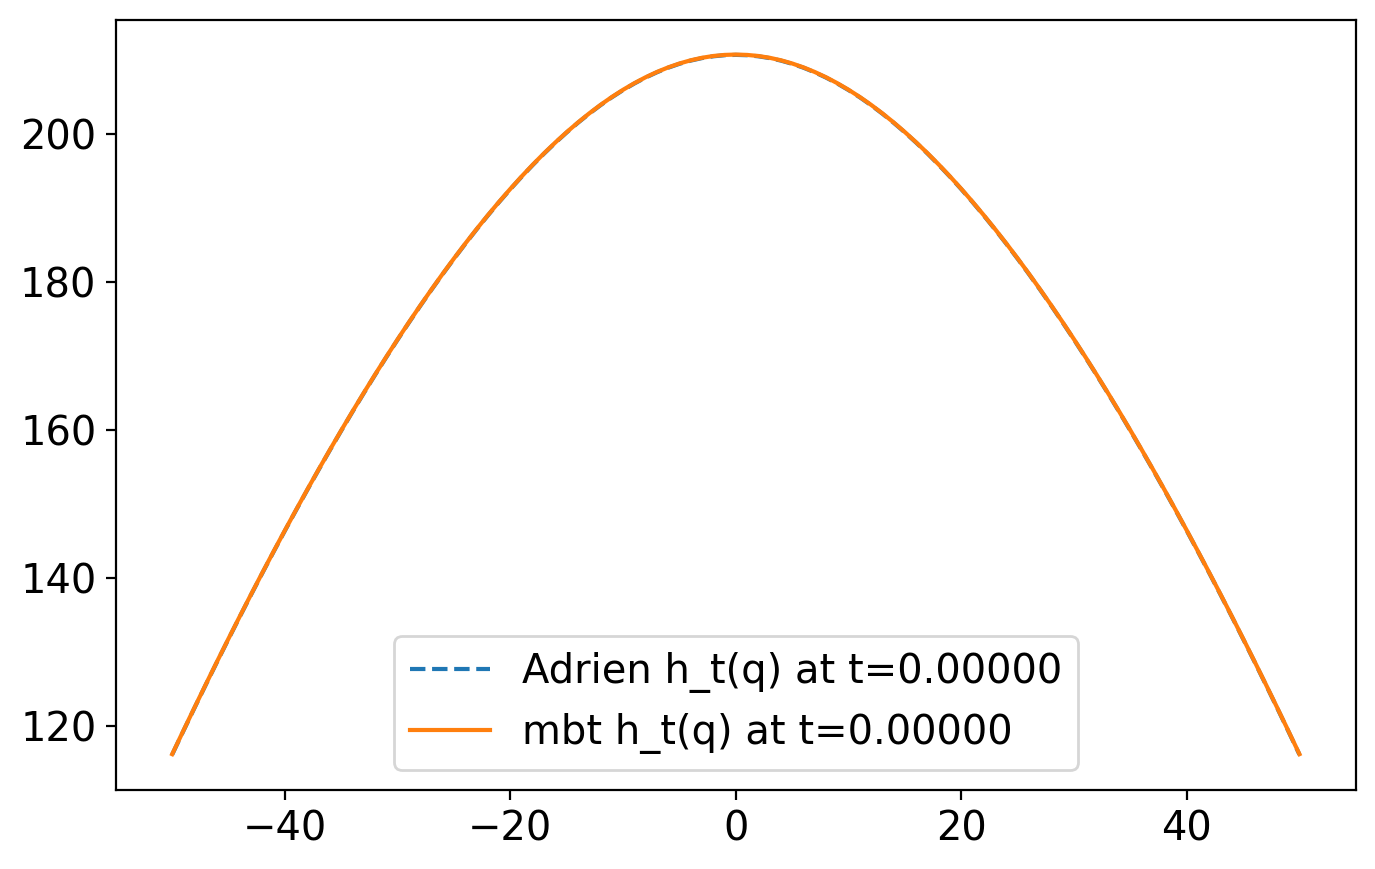

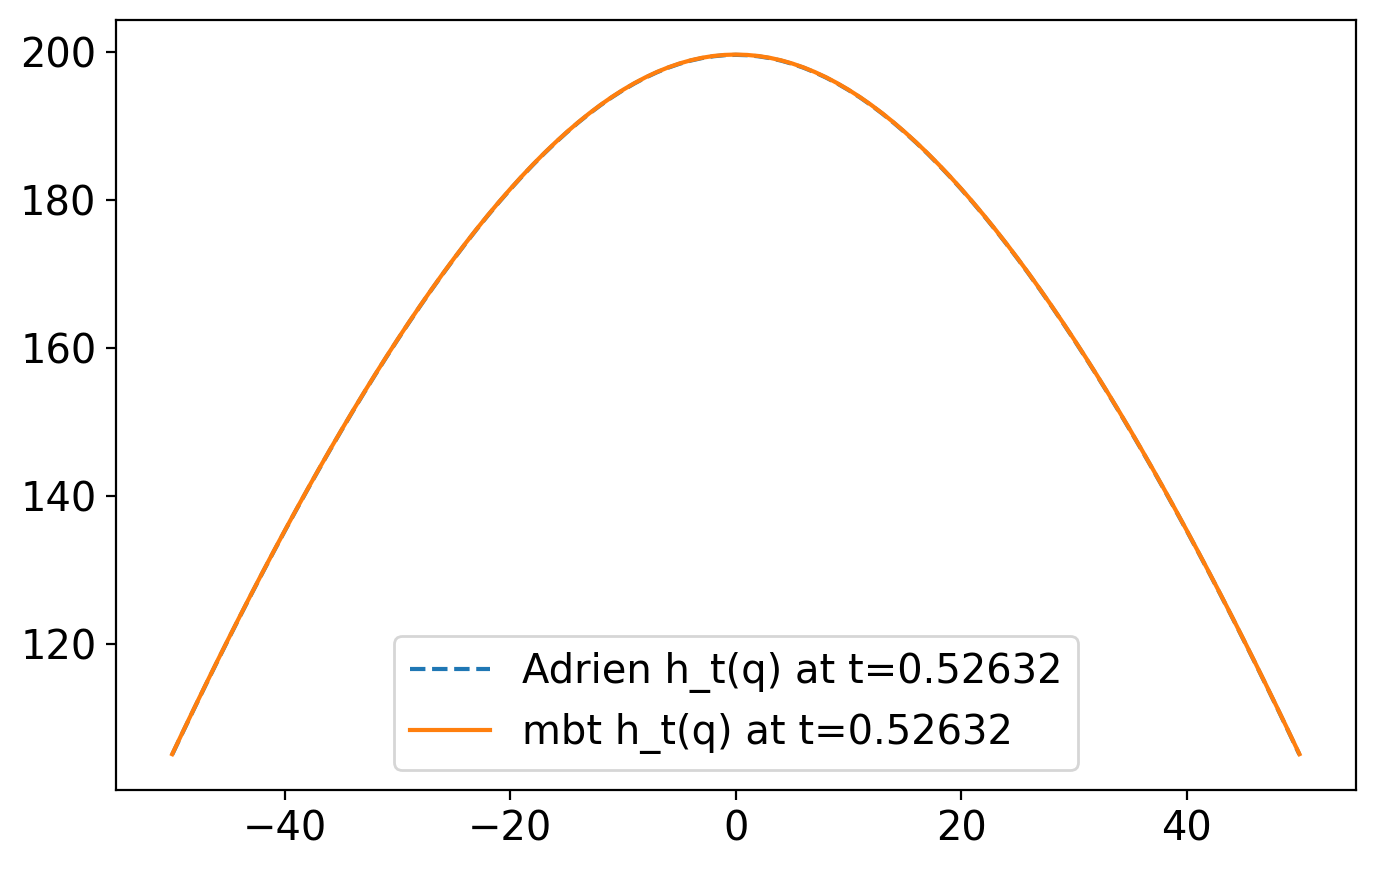

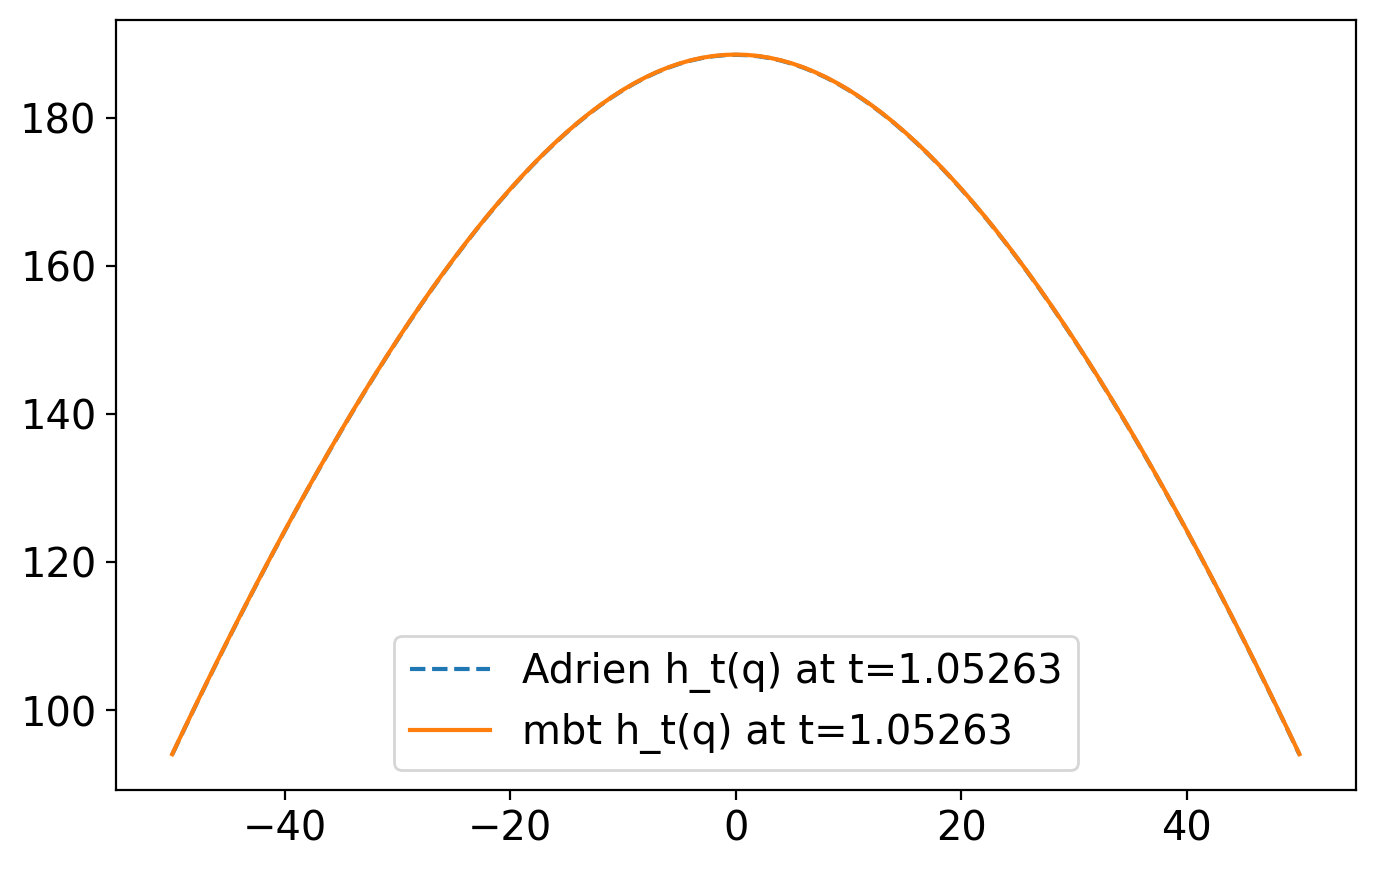

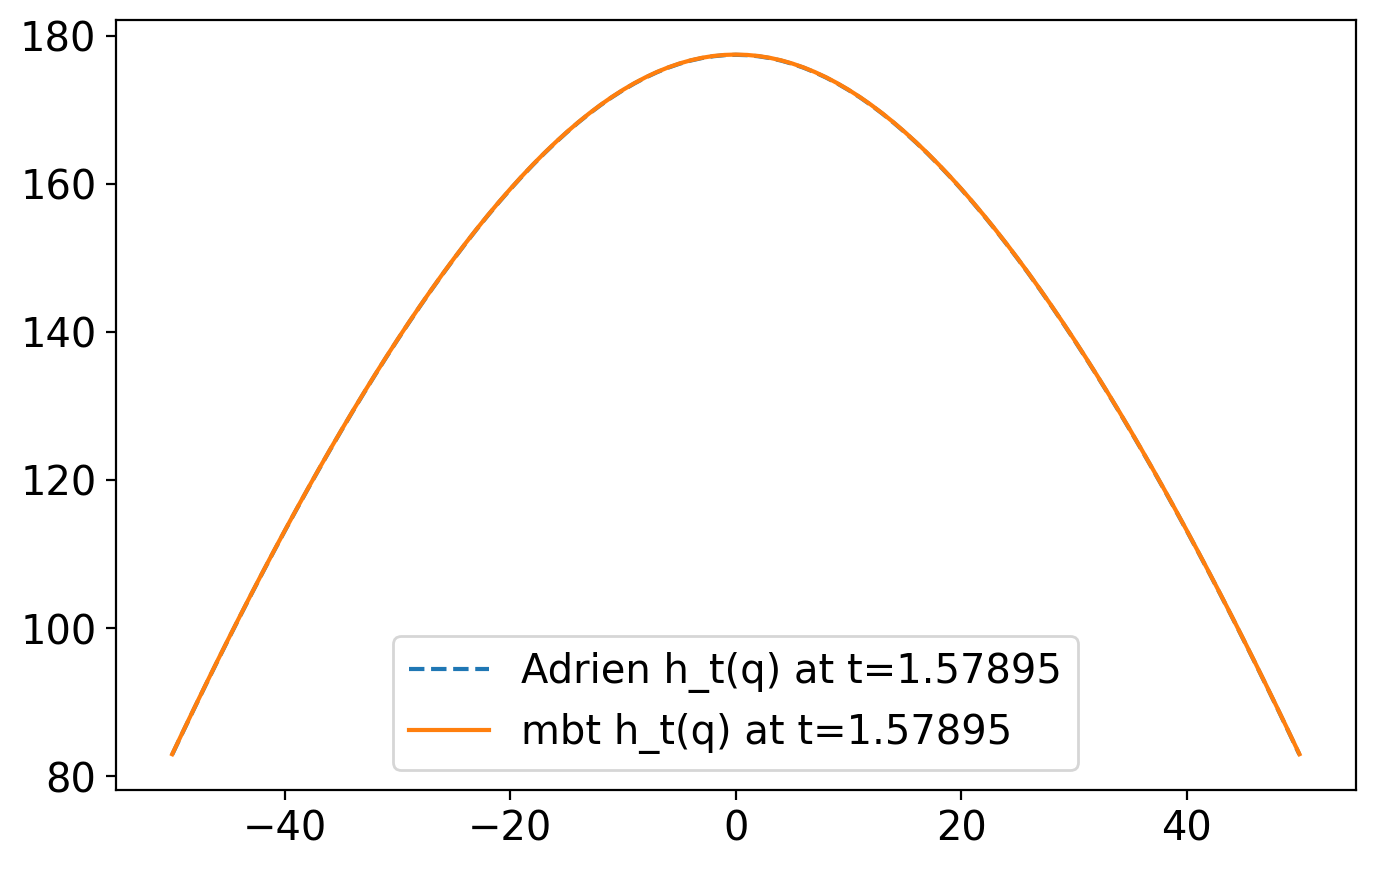

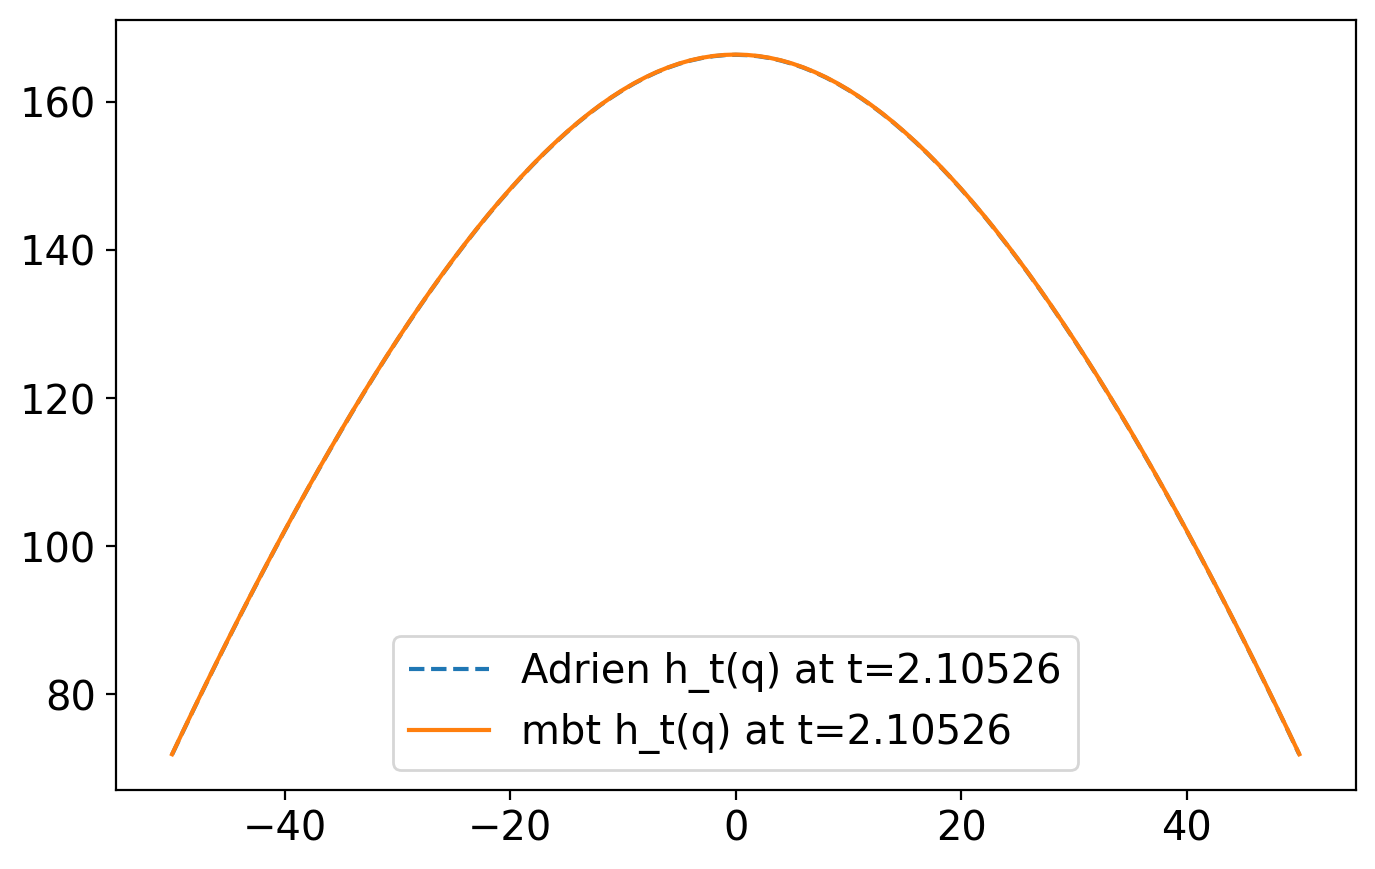

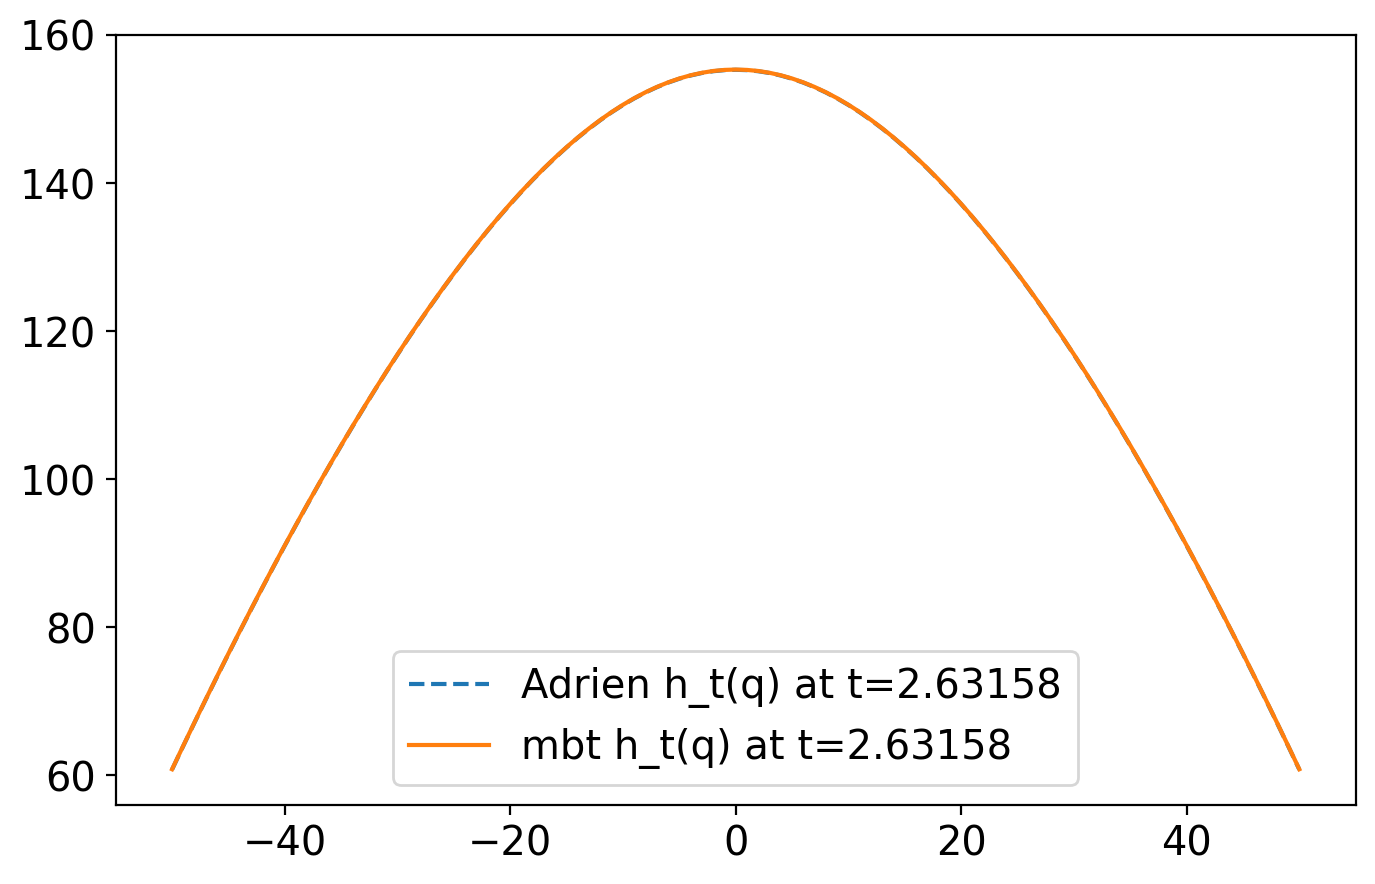

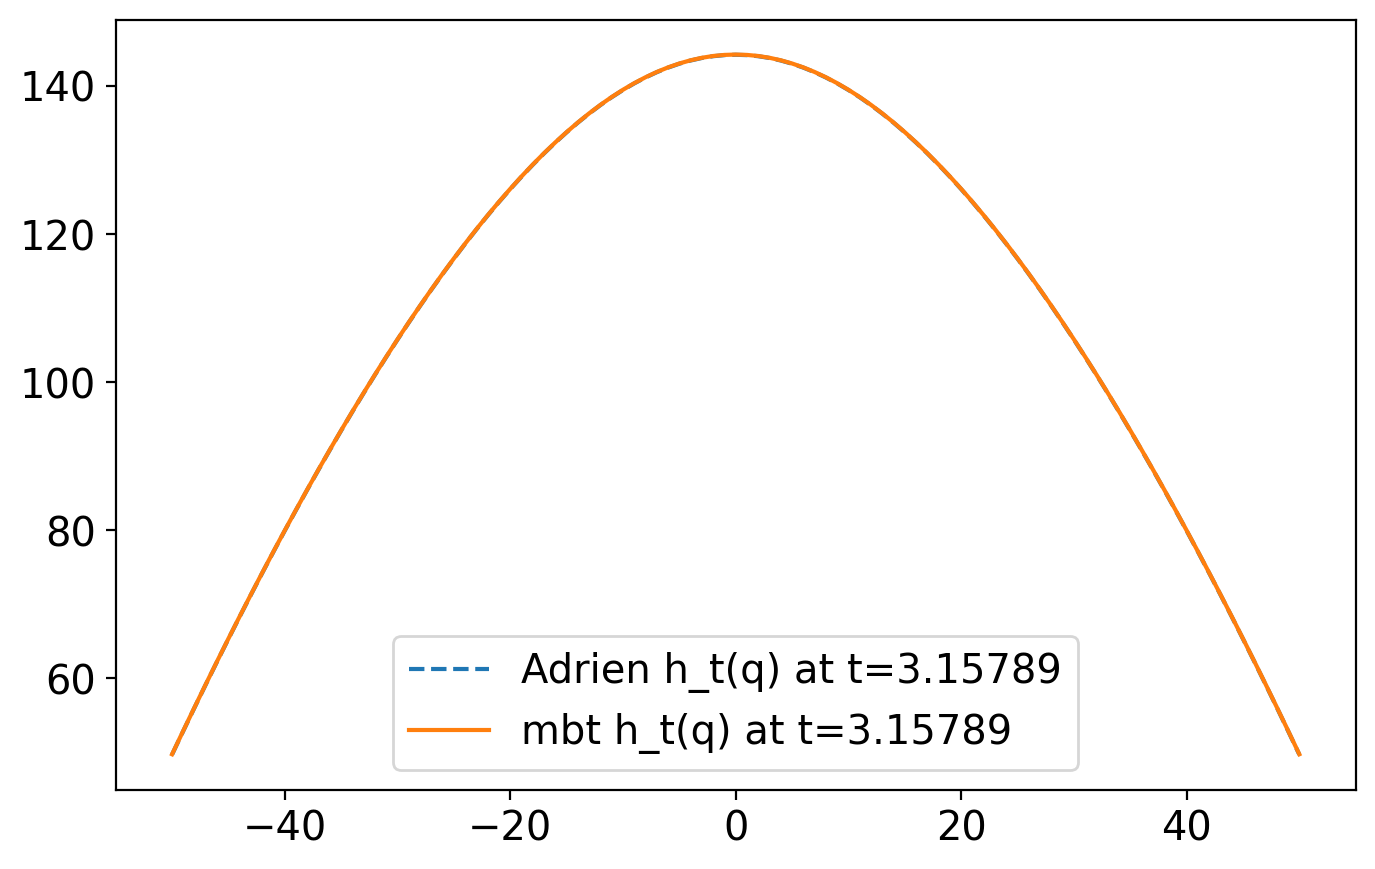

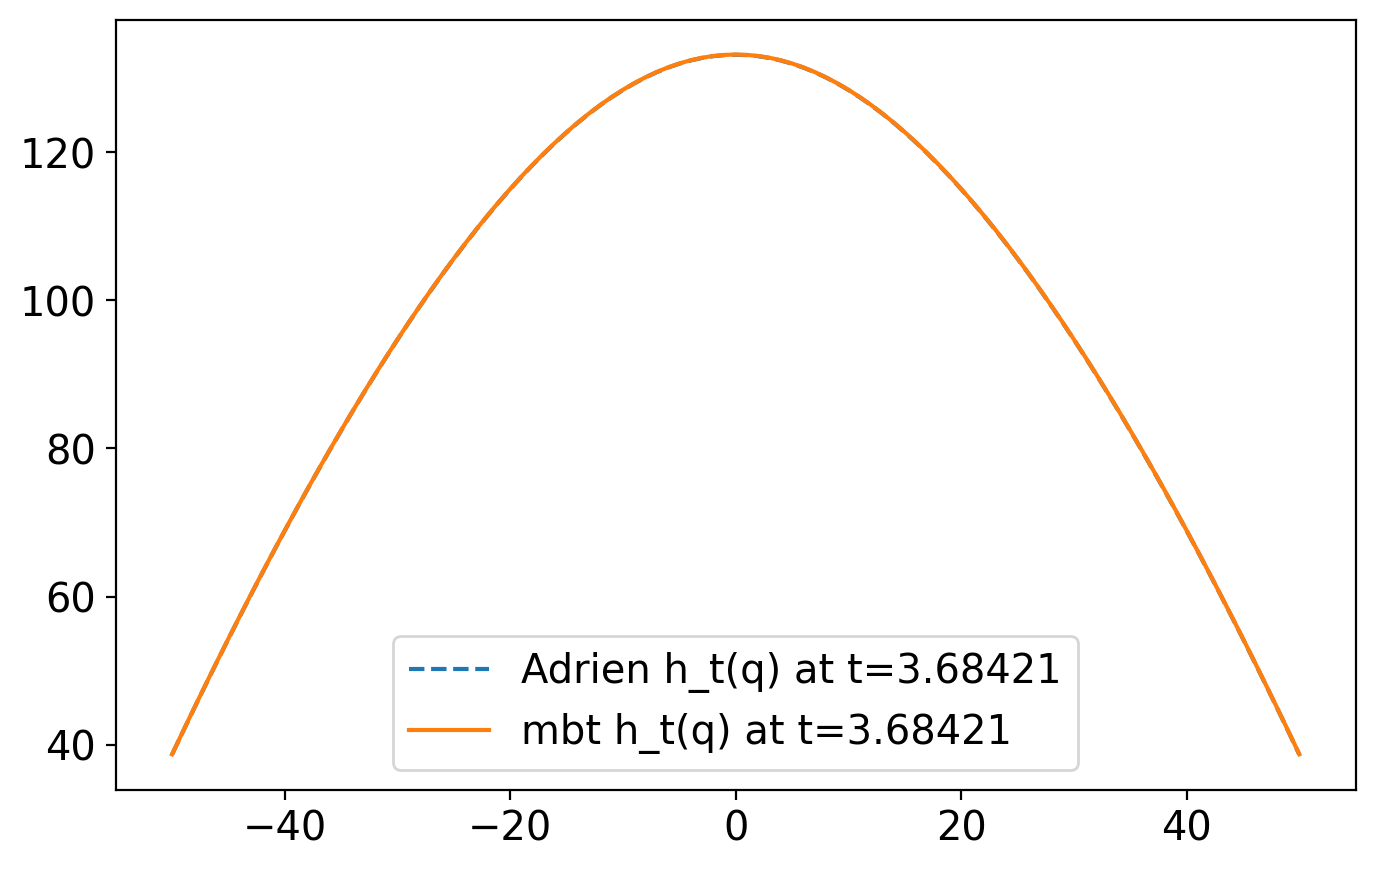

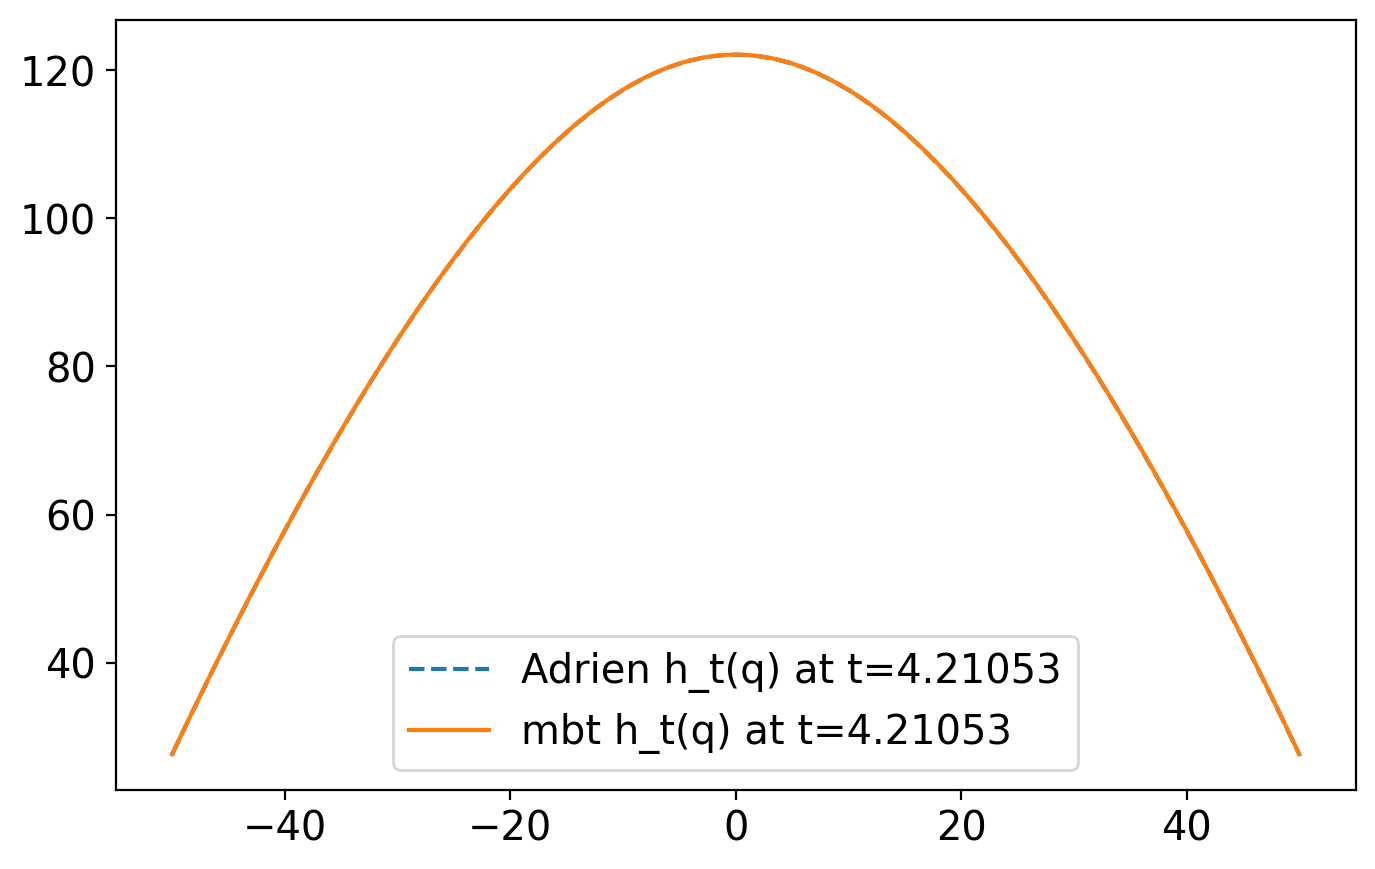

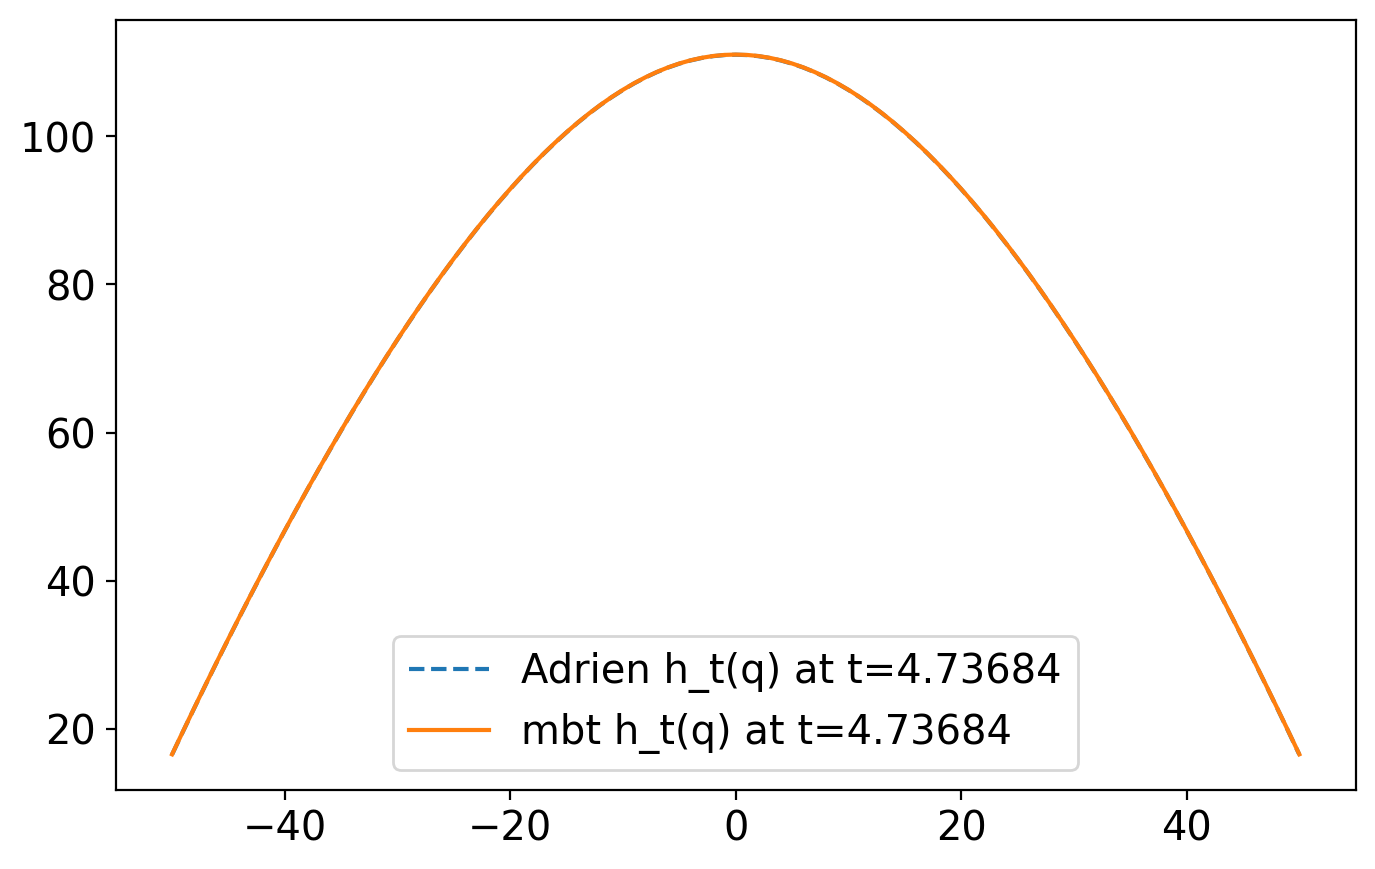

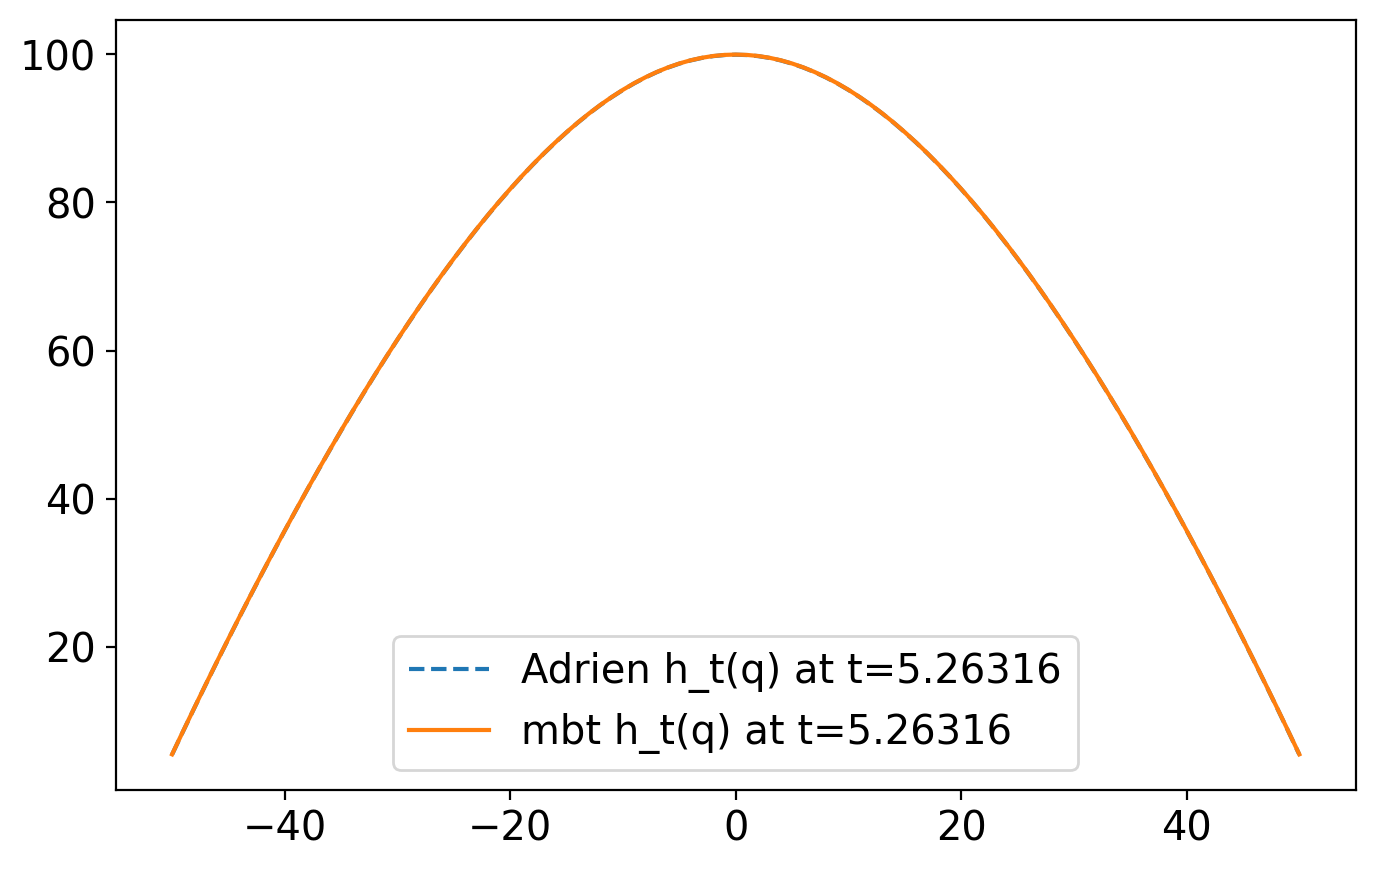

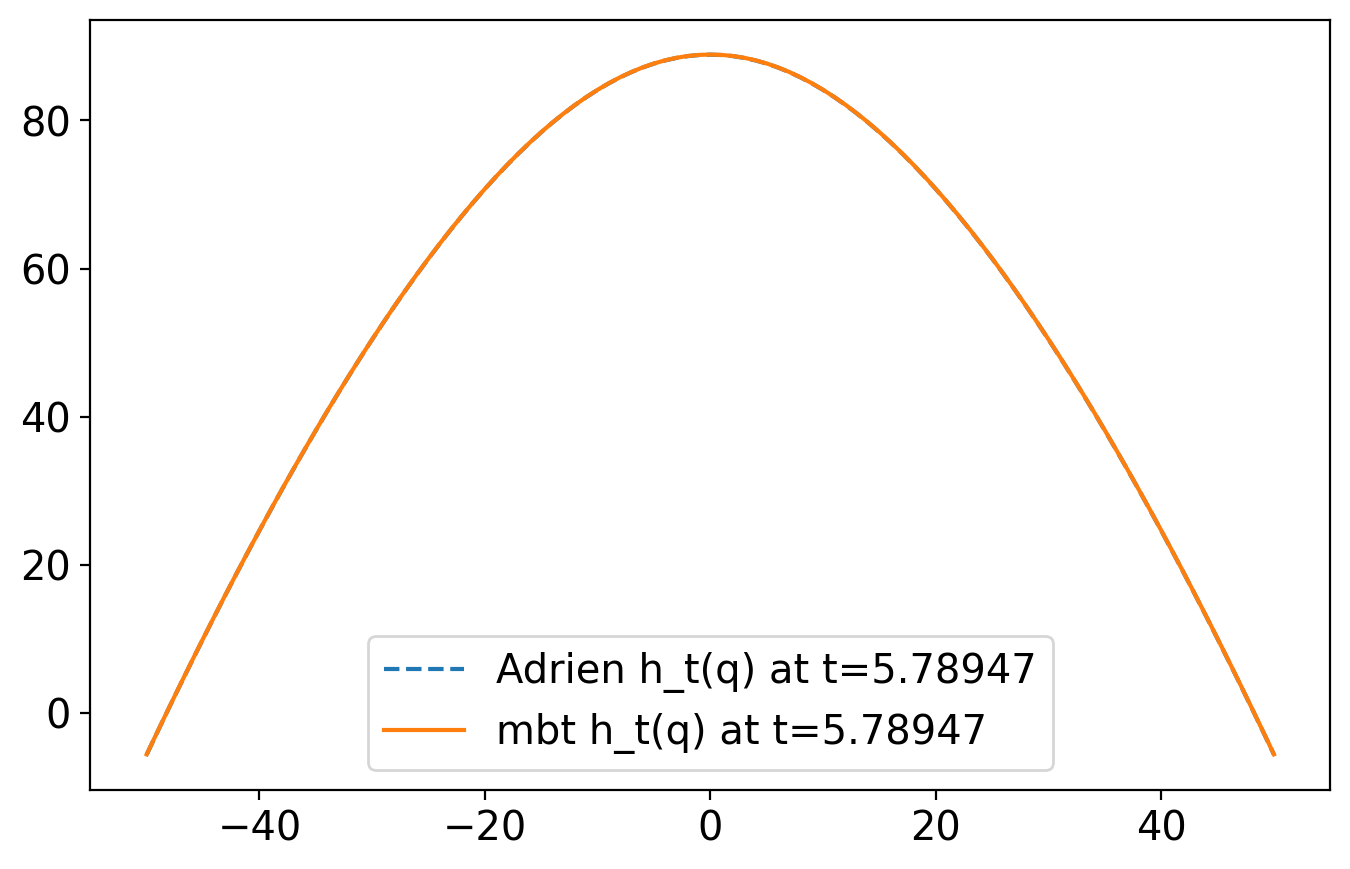

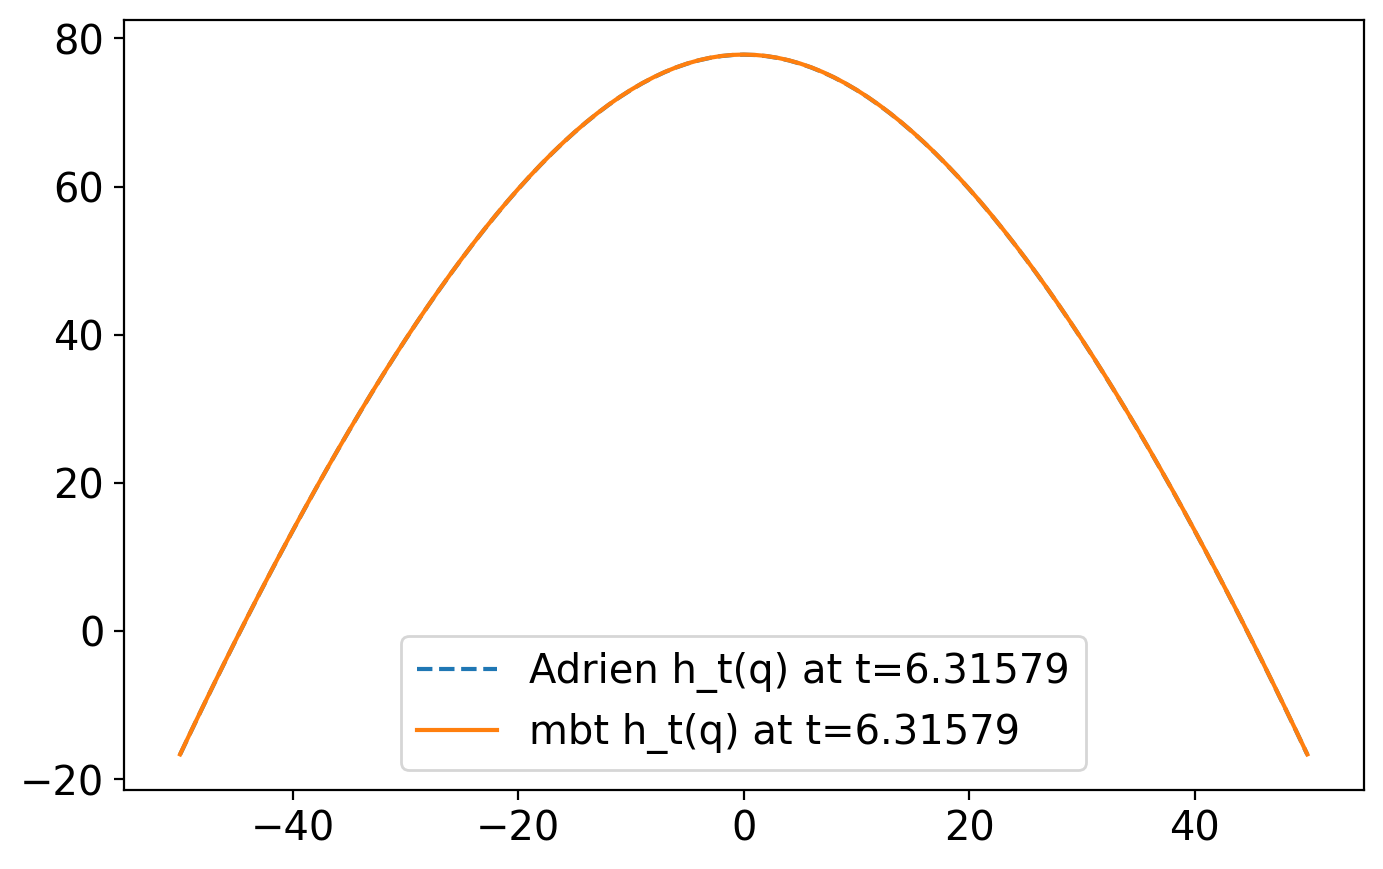

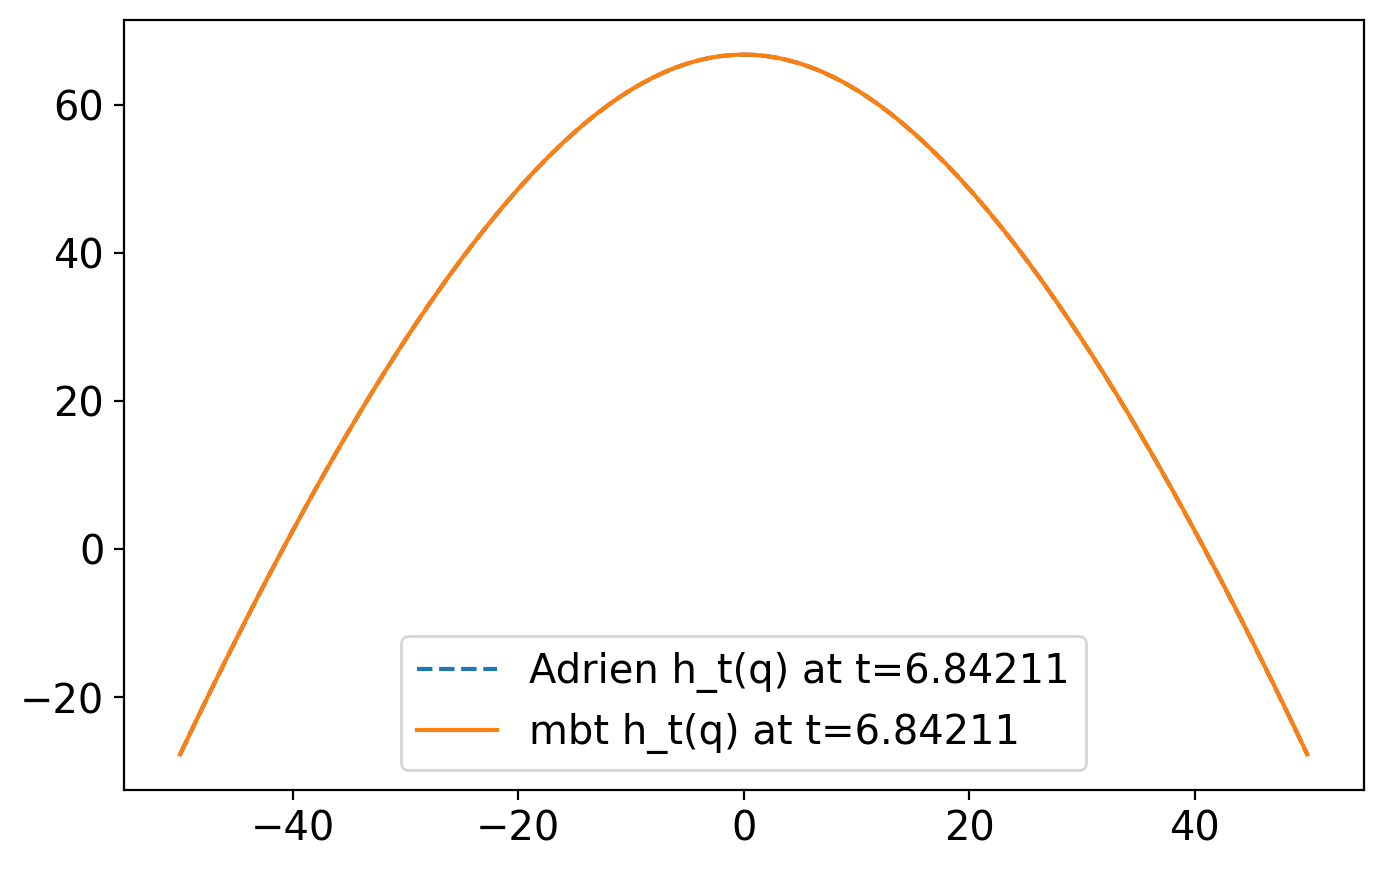

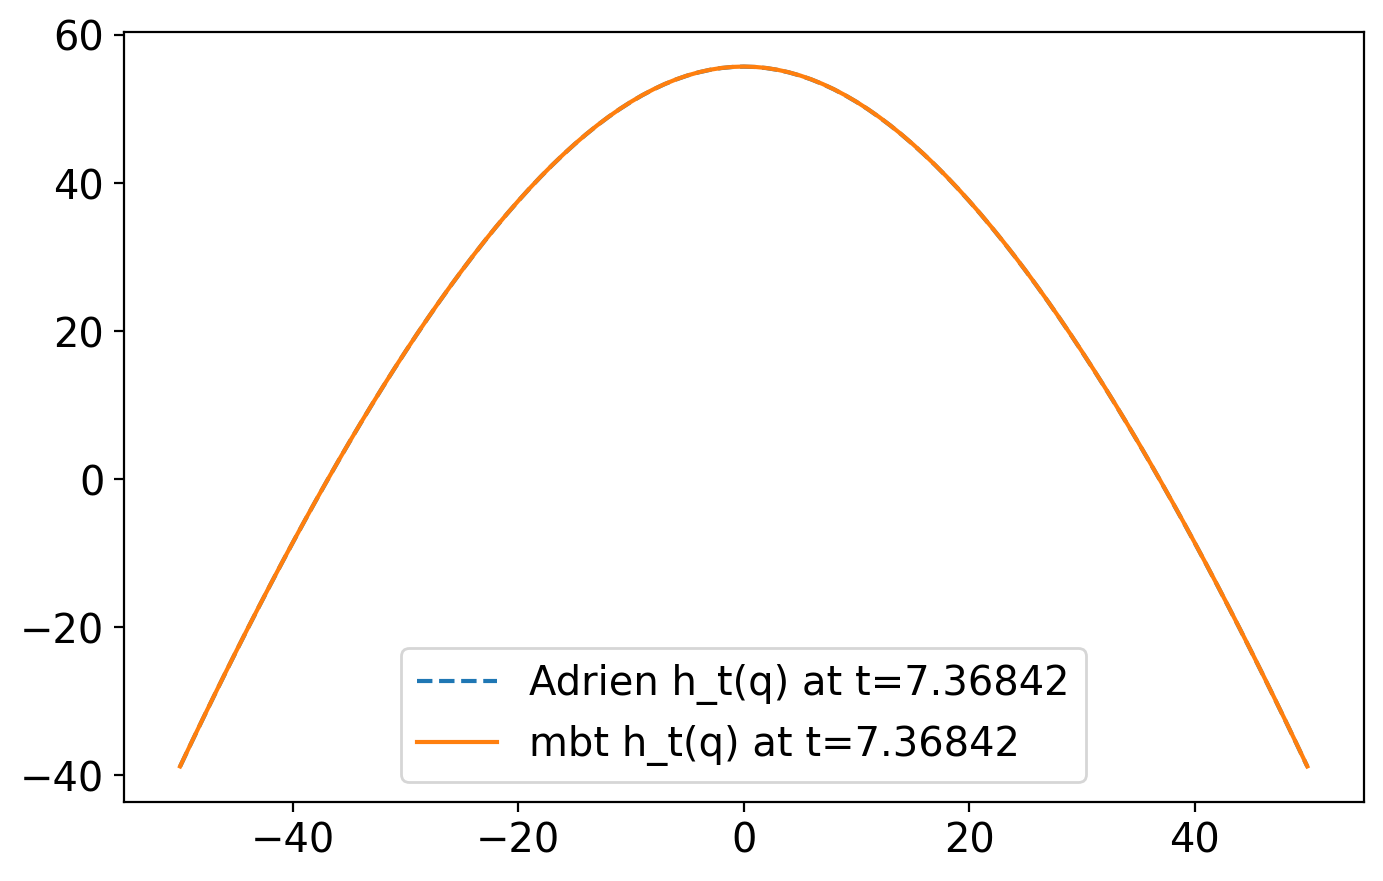

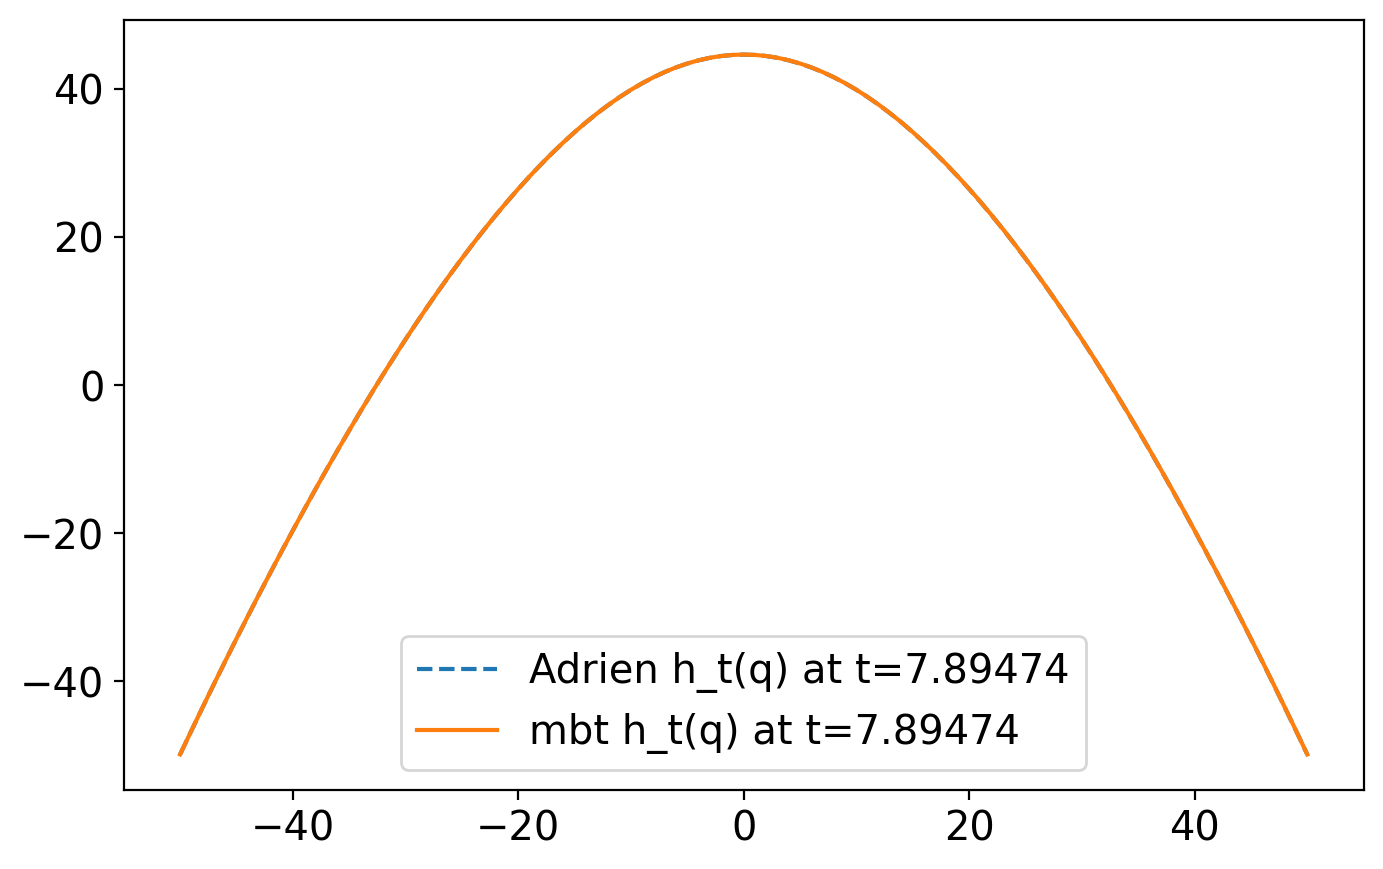

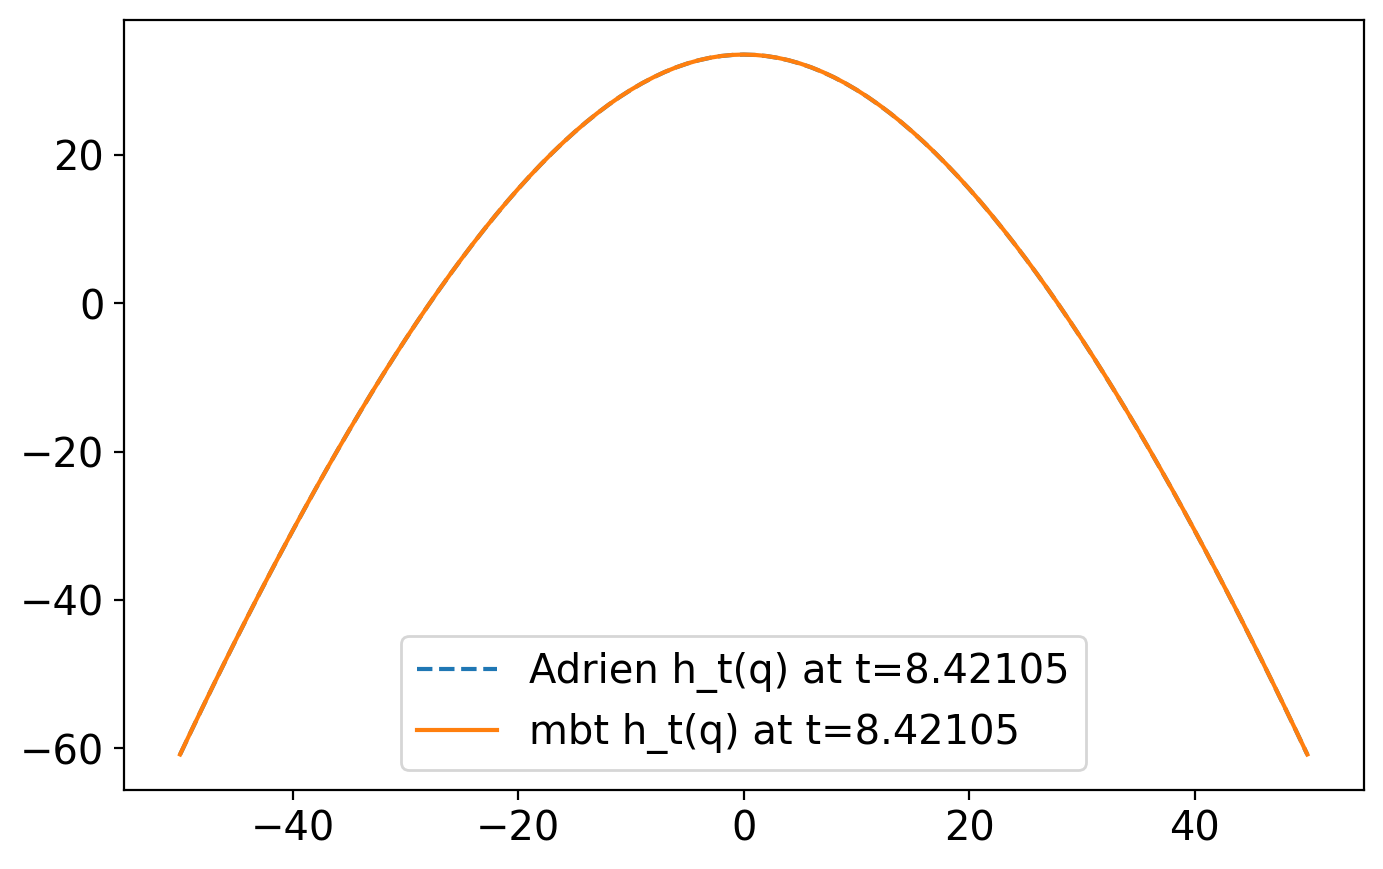

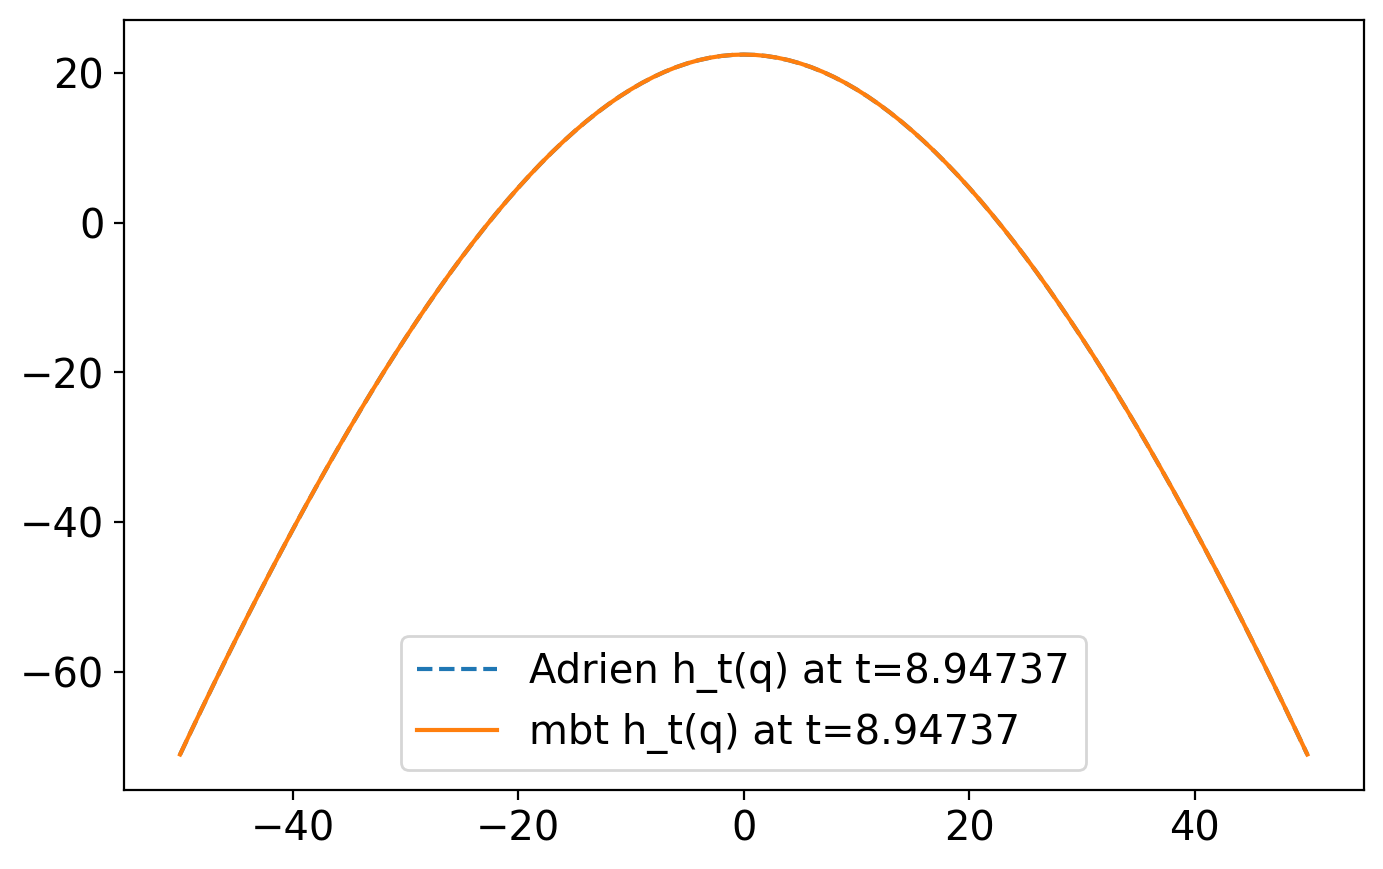

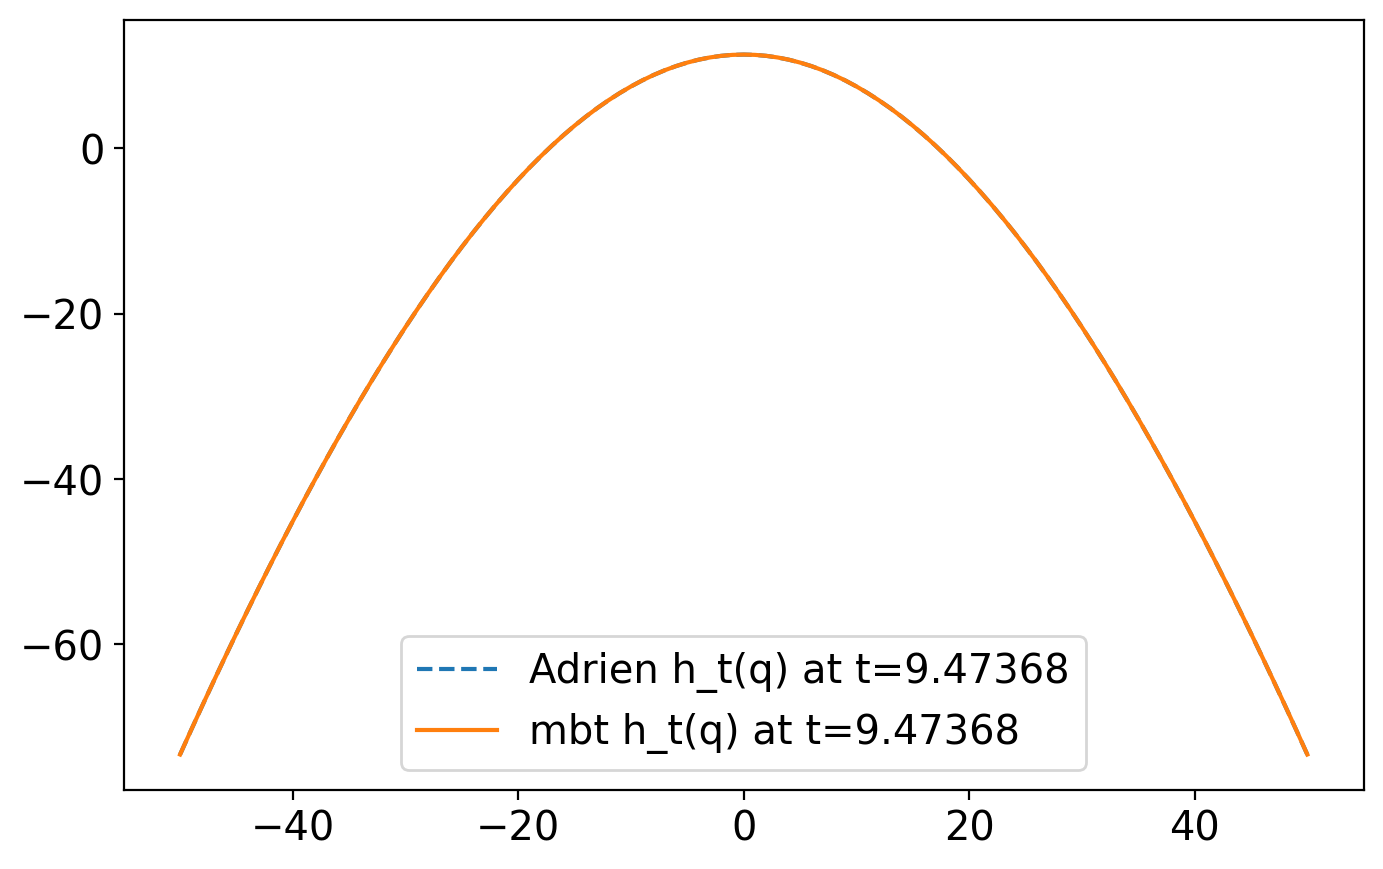

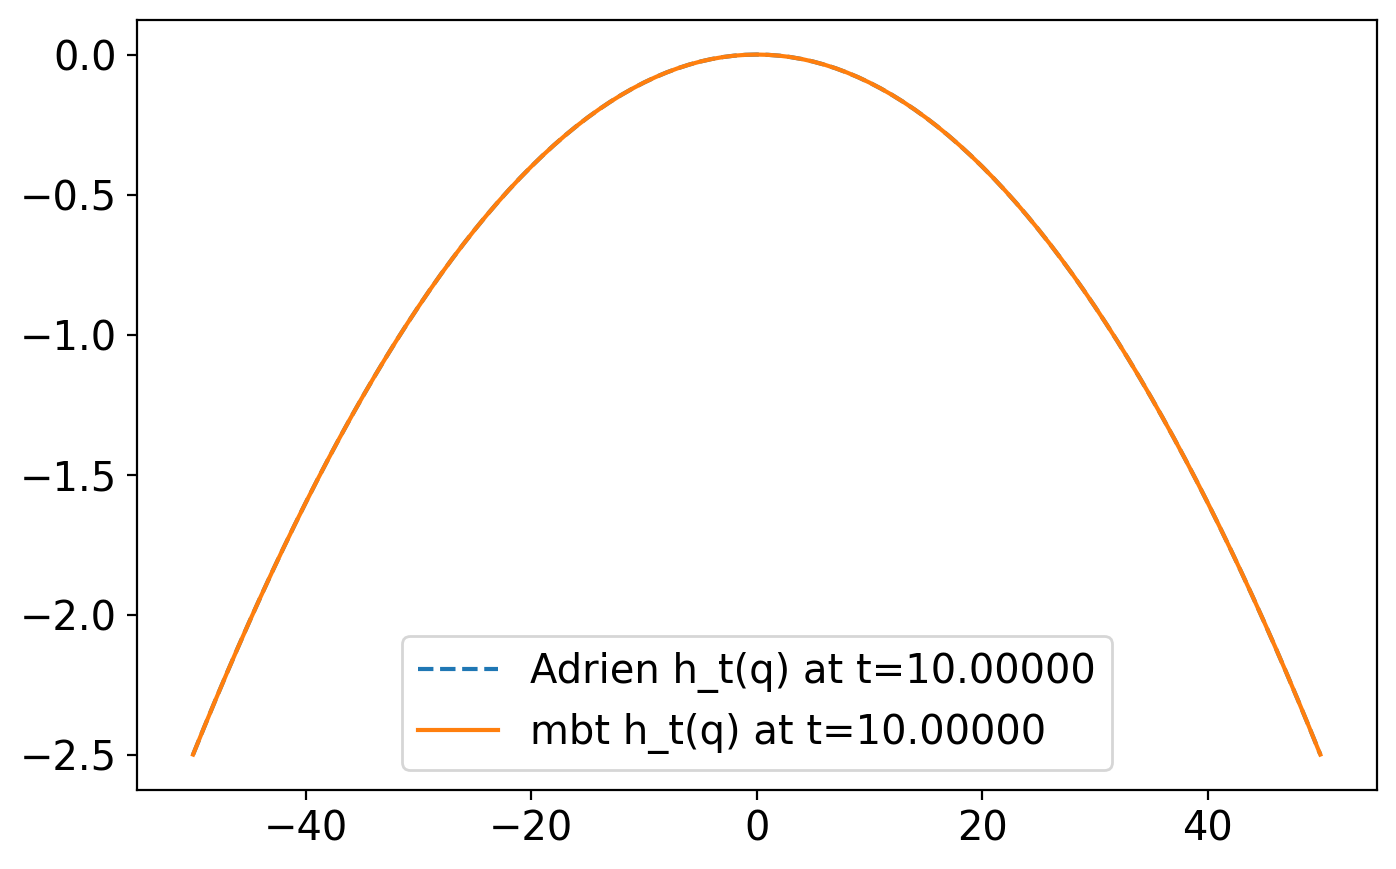

In [26]:

q_grid = np.arange(-env.max_inventory, env.max_inventory + 1)

h_mbt_list = []
for t in np.linspace(0, env.terminal_time, env.n_steps):
    h_mbt_list.append(agent_mbt._calculate_ht(t))
# print(np.array(h_dense_list).shape)
# print(agent_Adrien.matrix_CJ().shape)
h_Adrien = agent_Adrien.get_delta_CJ_matrix()
# print(np.array(h_sparse).shape)
# print("h sparse[0]",h_sparse[0].shape)
# print("h dense_list[0]",np.array(h_dense_list)[0].shape)
# print("t_vector head:", agent_Adrien.t_vector[:5])
# print("t_vector min/max:", agent_Adrien.t_vector.min(), agent_Adrien.t_vector.max())
# print("dt (mean):", np.mean(np.diff(agent_Adrien.t_vector)))
for i in range(len(h_Adrien)):
    plt.plot(q_grid, h_Adrien[i].flatten(), "--", label=f"Adrien h_t(q) at t={agent_Adrien.t_vector[i]:.5f}")
    plt.plot(q_grid, h_mbt_list[i], label=f"mbt h_t(q) at t={np.linspace(0, env.terminal_time, env.n_steps)[i]:.5f}")
    plt.legend()
    plt.show()


In [27]:
t_test = env.terminal_time / 2
idx = int(np.argmin(np.abs(agent_Adrien.t_vector - t_test)))
t_eval = float(agent_Adrien.t_vector[idx])
print(f"Using t_eval≈{t_eval:.5f} (idx={idx}) closest to t_test={t_test:.5f}")
ii=0
for t in np.linspace(0, env.terminal_time, env.n_steps):
    for q in [-5, 0, 5]:
        mbt_deltas = agent_mbt._calculate_deltas(t, np.array([q]))
        #print(mbt_deltas)
        mbt_ask, mbt_bid = mbt_deltas[0][0], mbt_deltas[0][1]
        Adrien_ask, Adrien_bid = agent_Adrien.get_delta_CJ_2(ii, np.array([q]))
    ii+=1

Using t_eval≈5.26316 (idx=10) closest to t_test=5.00000


Using t_eval≈5.26316 (idx=10) closest to t_test=5.00000
------------------------------------------------------------


/var/folders/kx/1mlzw51d67d3cr090d4kd9zc0000gn/T/ipykernel_25099/2401801753.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Adrien_ask, Adrien_bid = float(Adrien_result[0]), float(Adrien_result[1])


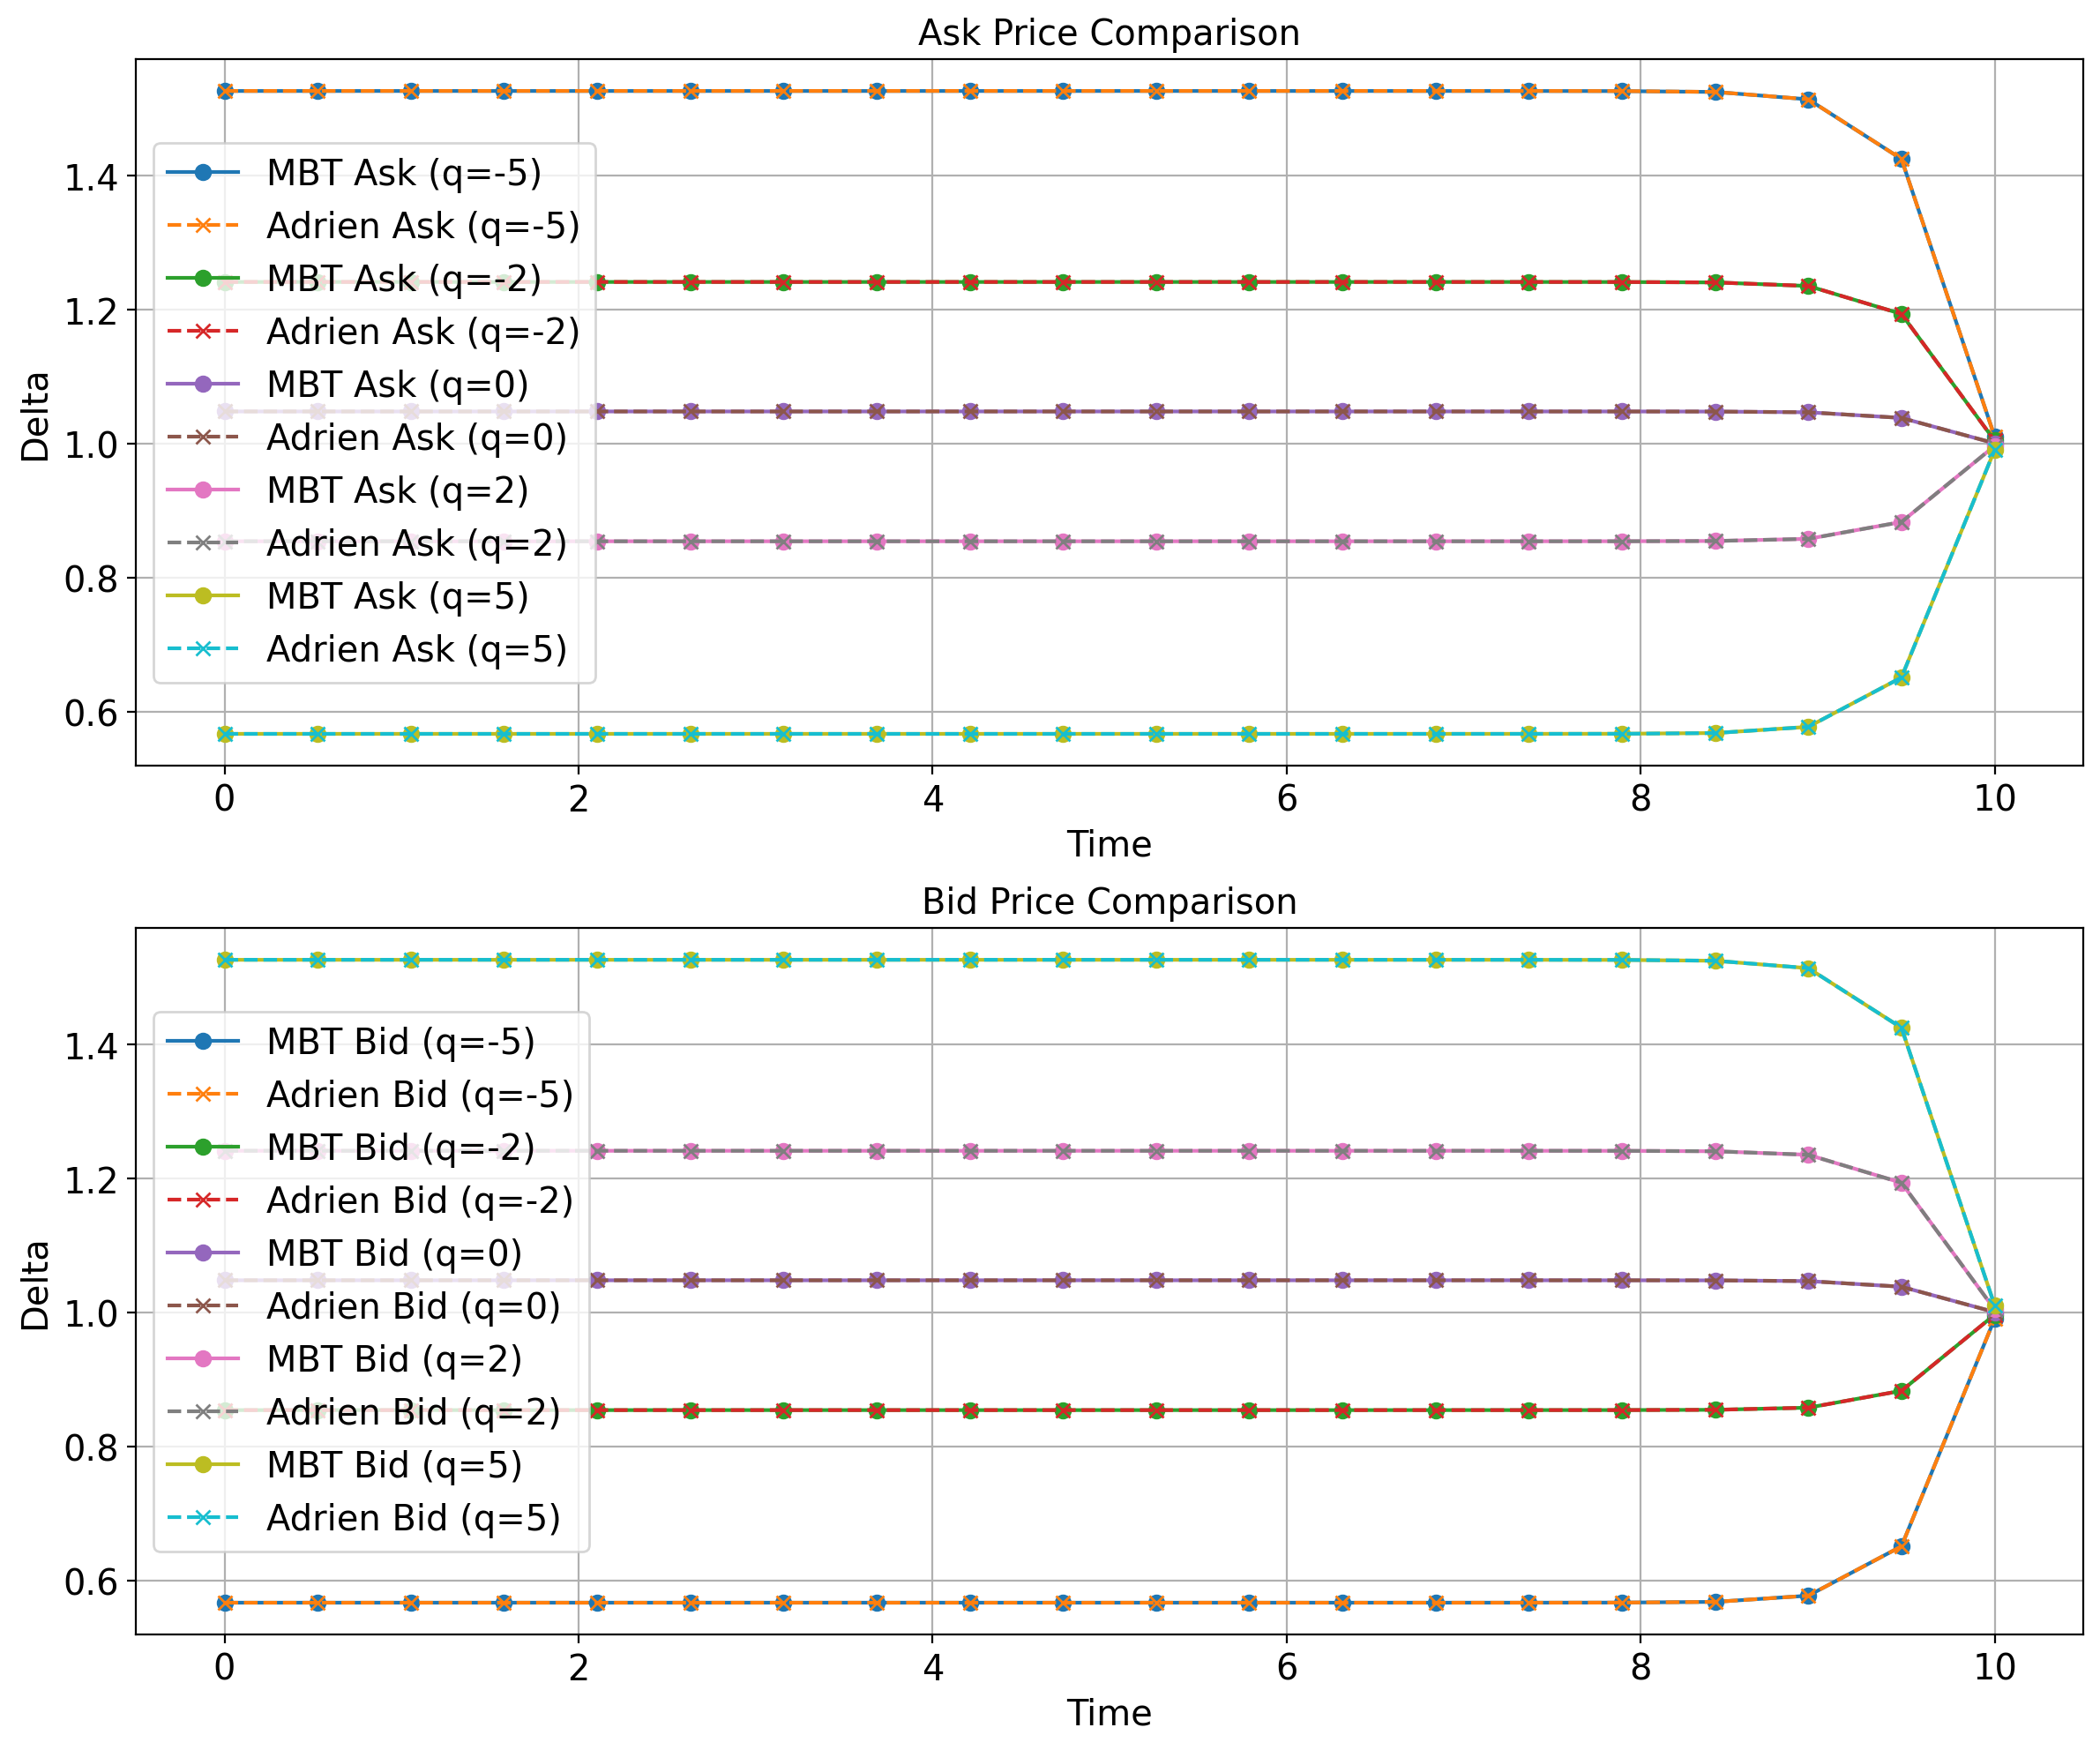

In [28]:
t_test = env.terminal_time / 2
idx = int(np.argmin(np.abs(agent_Adrien.t_vector - t_test)))
t_eval = float(agent_Adrien.t_vector[idx])
print(f"Using t_eval≈{t_eval:.5f} (idx={idx}) closest to t_test={t_test:.5f}")

# Store values for plotting
times = []
q_values_all = []
mbt_asks = []
mbt_bids = []
adrien_asks = []
adrien_bids = []

# Print comparison table
#print(f"\n{'Time':>8} {'q':>4} {'MBT Ask':>10} {'Adrien Ask':>10} {'MBT Bid':>10} {'Adrien Bid':>10}")
print("-" * 60)
q_values = [-5, -2, 0, 2, 5]
ii = 0
for t in np.linspace(0, env.terminal_time, env.n_steps):
    for q in q_values:
        mbt_deltas = agent_mbt._calculate_deltas(t, np.array([q]))
        mbt_bid, mbt_ask = float(mbt_deltas[0][0]), float(mbt_deltas[0][1])
        
        # Get Adrien's values and convert to float
        Adrien_result = agent_Adrien.get_delta_CJ_2(ii, np.array([q]))
        # Check if the result is a tuple or another type
        if isinstance(Adrien_result, tuple):
            Adrien_ask, Adrien_bid = float(Adrien_result[0]), float(Adrien_result[1])
        else:
            # If it's a numpy array or similar, extract appropriately
            Adrien_ask = float(Adrien_result[0] if hasattr(Adrien_result, '__getitem__') else Adrien_result)
            Adrien_bid = float(Adrien_result[1] if hasattr(Adrien_result, '__getitem__') else Adrien_result)
        
        # Print comparison row
        #print(f"{t:8.5f} {q:4d} {mbt_ask:10.6f} {Adrien_ask:10.6f} {mbt_bid:10.6f} {Adrien_bid:10.6f}")
        
        # Store for plotting
        times.append(t)
        q_values_all.append(q)
        mbt_asks.append(mbt_ask)
        mbt_bids.append(mbt_bid)
        adrien_asks.append(Adrien_ask)
        adrien_bids.append(Adrien_bid)
    ii += 1

# Plot the comparison
plt.figure(figsize=(12, 10))


# Create subplot for ask prices
plt.subplot(2, 1, 1)
for q in q_values:
    # Filter data for this q value
    mask = [q_val == q for q_val in q_values_all]
    t_vals = [times[i] for i, m in enumerate(mask) if m]
    mbt_ask_vals = [mbt_asks[i] for i, m in enumerate(mask) if m]
    adrien_ask_vals = [adrien_asks[i] for i, m in enumerate(mask) if m]
    
    plt.plot(t_vals, mbt_ask_vals, 'o-', label=f'MBT Ask (q={q})')
    plt.plot(t_vals, adrien_ask_vals, 'x--', label=f'Adrien Ask (q={q})')

plt.title('Ask Price Comparison')
plt.xlabel('Time')
plt.ylabel('Delta')
plt.legend()
plt.grid(True)

# Create subplot for bid prices
plt.subplot(2, 1, 2)
for q in q_values:
    # Filter data for this q value
    mask = [q_val == q for q_val in q_values_all]
    t_vals = [times[i] for i, m in enumerate(mask) if m]
    mbt_bid_vals = [mbt_bids[i] for i, m in enumerate(mask) if m]
    adrien_bid_vals = [adrien_bids[i] for i, m in enumerate(mask) if m]
    
    plt.plot(t_vals, mbt_bid_vals, 'o-', label=f'MBT Bid (q={q})')
    plt.plot(t_vals, adrien_bid_vals, 'x--', label=f'Adrien Bid (q={q})')

plt.title('Bid Price Comparison')
plt.xlabel('Time')
plt.ylabel('Delta')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
# Add this diagnostic cell

print("=== Time Grid Comparison ===")
print(f"Terminal Time: {terminal_time}")
print(f"n_steps: {n_steps}")
print(f"params_env['N_t']: {params_env['N_t']}")

# Check Adrien's time grid
print(f"\nAdrien's t_vector length: {len(agent_Adrien.t_vector)}")
print(f"Adrien's t_vector first 3: {agent_Adrien.t_vector[:3]}")
print(f"Adrien's t_vector last 3: {agent_Adrien.t_vector[-3:]}")
print(f"Adrien's delta_t: {agent_Adrien.delta_t}")

# Check MBT time grid
mbt_times = np.linspace(0, env.terminal_time, env.n_steps)
print(f"\nMBT time grid length: {len(mbt_times)}")
print(f"MBT time grid first 3: {mbt_times[:3]}")
print(f"MBT time grid last 3: {mbt_times[-3:]}")
print(f"MBT step size: {mbt_times[1] - mbt_times[0]}")

# Check if grids are identical
if len(agent_Adrien.t_vector) == len(mbt_times):
    max_diff = np.max(np.abs(agent_Adrien.t_vector - mbt_times))
    print(f"\nMax difference between grids: {max_diff}")
else:
    print(f"\nWARNING: Grid lengths don't match! Adrien: {len(agent_Adrien.t_vector)}, MBT: {len(mbt_times)}")

# Check terminal condition explicitly
print(f"\n=== Terminal Condition (at t=T) ===")
print(f"Adrien h_T at q=0: {h_Adrien[-1].flatten()[max_inventory]}")
print(f"Expected h_T at q=0: {-alpha * 0**2} (should be 0 for q=0)")

# Check MBT terminal condition
h_mbt_at_T = agent_mbt._calculate_ht(terminal_time)
print(f"MBT h_T at q=0: {h_mbt_at_T[max_inventory]}")

=== Time Grid Comparison ===
Terminal Time: 10.0
n_steps: 20
params_env['N_t']: 20

Adrien's t_vector length: 20
Adrien's t_vector first 3: [0.         0.52631579 1.05263158]
Adrien's t_vector last 3: [ 8.94736842  9.47368421 10.        ]
Adrien's delta_t: 0.5

MBT time grid length: 20
MBT time grid first 3: [0.         0.52631579 1.05263158]
MBT time grid last 3: [ 8.94736842  9.47368421 10.        ]
MBT step size: 0.5263157894736842

Max difference between grids: 0.0

=== Terminal Condition (at t=T) ===
Adrien h_T at q=0: 0.0
Expected h_T at q=0: -0.0 (should be 0 for q=0)
MBT h_T at q=0: [0.]


In [30]:
# Add diagnostic cell to check A matrices
print("=== Comparing A Matrices ===")

# Get Adrien's matrix
adrien_matrix = agent_Adrien.matrix_CJ().toarray()  # Convert sparse to dense
print(f"Adrien matrix shape: {adrien_matrix.shape}")

# Get MBT's matrix
mbt_matrix = agent_mbt.a_matrix
print(f"MBT matrix shape: {mbt_matrix.shape}")

# Check off-diagonal values
print(f"\nAdrien off-diagonal value: {(params_env['varphi'] + agent_Adrien.psi * agent_Adrien.aux_integral/terminal_time) * np.exp(-1)}")
print(f"MBT bid lambda: {agent_mbt.lambdas[BID_INDEX] * np.exp(-1)}")
print(f"MBT ask lambda: {agent_mbt.lambdas[ASK_INDEX] * np.exp(-1)}")

# Compare diagonal elements at q=0
q_zero_idx_adrien = params_env['q_bar']  # Adrien's index for q=0
q_zero_idx_mbt = agent_mbt.max_inventory  # MBT's index for q=0

print(f"\nDiagonal at q=0:")
print(f"Adrien: {adrien_matrix[q_zero_idx_adrien, q_zero_idx_adrien]}")
print(f"MBT: {mbt_matrix[q_zero_idx_mbt, q_zero_idx_mbt]}")

# Compare diagonal at q=5
q_five_idx_adrien = params_env['q_bar'] + 5
q_five_idx_mbt = agent_mbt.max_inventory - 5  # Note the minus!

print(f"\nDiagonal at q=5:")
print(f"Adrien (index {q_five_idx_adrien}): {adrien_matrix[q_five_idx_adrien, q_five_idx_adrien]}")
print(f"MBT (index {q_five_idx_mbt}): {mbt_matrix[q_five_idx_mbt, q_five_idx_mbt]}")

# Print a few rows to visualize
print("\n=== Adrien's A matrix (first 3 rows) ===")
print(adrien_matrix[:3, :5])

print("\n=== MBT's A matrix (first 3 rows) ===")
print(mbt_matrix[:3, :5])

# Check if matrices are equal (accounting for potential index reversal)
print("\n=== Matrix Equality Check ===")
# Try comparing with flipped MBT matrix
mbt_flipped = np.flip(np.flip(mbt_matrix, 0), 1)
print(f"Max difference (direct): {np.max(np.abs(adrien_matrix - mbt_matrix))}")
print(f"Max difference (flipped): {np.max(np.abs(adrien_matrix - mbt_flipped))}")

=== Comparing A Matrices ===
Adrien matrix shape: (101, 101)
MBT matrix shape: (101, 101)

Adrien off-diagonal value: 11.03638323514327
MBT bid lambda: [11.03860858]
MBT ask lambda: [11.03860858]

Diagonal at q=0:
Adrien: 0.0
MBT: -0.0

Diagonal at q=5:
Adrien (index 55): -2.5
MBT (index 45): -2.5

=== Adrien's A matrix (first 3 rows) ===
[[-250.           11.03638324    0.            0.            0.        ]
 [  11.03638324 -240.1          11.03638324    0.            0.        ]
 [   0.           11.03638324 -230.4          11.03638324    0.        ]]

=== MBT's A matrix (first 3 rows) ===
[[-250.           11.03860858    0.            0.            0.        ]
 [  11.03860858 -240.1          11.03860858    0.            0.        ]
 [   0.           11.03860858 -230.4          11.03860858    0.        ]]

=== Matrix Equality Check ===
Max difference (direct): 0.002225347860678184
Max difference (flipped): 0.002225347860678184


In [31]:
# Check what lambdas are being computed
print("=== Lambda Investigation ===")
print(f"Expected lambda (Adrien): {(params_env['varphi'] + agent_Adrien.psi * agent_Adrien.aux_integral/terminal_time) * np.exp(-1)}")
print(f"Actual MBT lambdas: {agent_mbt.lambdas}")

# Check the arrival model
print(f"\nArrival model phi: {phi}")
print(f"Arrival model psi: {psi}")
print(f"Arrival model gamma: {gamma}")

# The lambda should be:
expected_lambda = (phi + psi * agent_Adrien.aux_integral/terminal_time) * np.exp(-1)
print(f"\nExpected lambda: {expected_lambda}")
print(f"MBT is using: {agent_mbt.lambdas[0]}")
print(f"Ratio: {expected_lambda / agent_mbt.lambdas[0]}")

=== Lambda Investigation ===
Expected lambda (Adrien): 11.03638323514327
Actual MBT lambdas: [[30.00604912]
 [30.00604912]]

Arrival model phi: 15
Arrival model psi: 14.872268355662614
Arrival model gamma: 1

Expected lambda: 11.03638323514327
MBT is using: [30.00604912]
Ratio: [0.36780528]
